In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys
BASE = '/content/drive/Othercomputers/My Computer/Clone From Github/ECS170-Project'
sys.path.append(BASE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


************ Start ************
dataset: ORL dataset , method: cnn , setting: train test split , result: saver , evaluation: multi-metric evaluator
loading data from ORL...
method running...
--start training...
evaluating performance...
Accuracy: 0.07777777777777778
Precision (weighted): 0.0114165685824672
Precision (macro): 0.0114165685824672
Precision (micro): 0.07777777777777778
Recall (weighted): 0.07777777777777778
Recall (macro): 0.07777777777777778
Recall (micro): 0.07777777777777778
F1 (weighted): 0.018888350211879627
F1 (macro): 0.018888350211879623
F1 (micro): 0.07777777777777778
Confusion Matrix:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 9 0 0]
 ...
 [0 0 0 ... 9 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 6 0 0]]
Epoch: 0  Accuracy: 0.0778  Loss: 9.3236
evaluating performance...
Accuracy: 0.13333333333333333
Precision (weighted): 0.08962110995850622
Precision (macro): 0.08962110995850622
Precision (micro): 0.13333333333333333
Recall (weighted): 0.13333333333333333
Recall (m

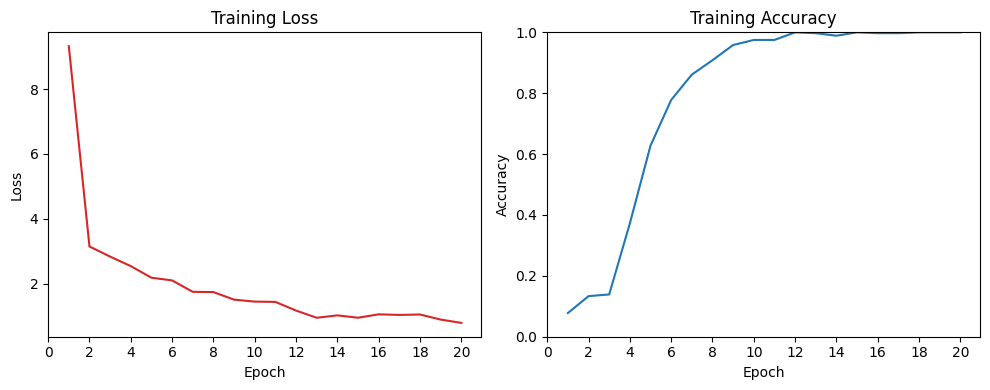

In [3]:
from local_code.stage_3_code.Dataset_Loader import Dataset_Loader
from local_code.stage_3_code.Method_CNN import Method_CNN
from local_code.stage_3_code.Result_Saver import Result_Saver
from local_code.stage_3_code.Setting_Train_Test_Split import Setting_Train_Test_Split
from local_code.stage_3_code.Evaluate_Accuracy import Evaluate_Accuracy

import numpy as np
import torch
import os

# ---- Multi-Layer Perceptron script ----
if 1:
    # ---- parameter section -------------------------------
    np.random.seed(2) #Neural networks usually start with random weights, these fix the randomness
    torch.manual_seed(2)
    # ------------------------------------------------------

    # ---- object initialization section -------------------
    data_obj = Dataset_Loader(
        'ORL dataset',
        'face dataset',
        folder_path=f'{BASE}/data/stage_3_data', #changed data folder pathway
        file_name='ORL'
    )

    method_obj = Method_CNN(
    'cnn',
    '',
    input_channels=1,
    num_classes=40,
    input_height=112,
    input_width=92
    )
    method_obj.learning_rate = 1e-3
    method_obj.max_epoch = 20

    result_obj = Result_Saver('saver', '')
    result_obj.result_destination_folder_path = f'{BASE}/result/stage_3_result/CNN_' #changed result folder pathway so it is inside of project folder
    result_obj.result_destination_file_name = 'ORL_prediction_result'

    setting_obj = Setting_Train_Test_Split('train test split', '')

    # ---- evaluate section ---------------------------------
    evaluate_obj = Evaluate_Accuracy('multi-metric evaluator', '') #changed accuracy to multi-metric
 

    # ---- running section ---------------------------------
    print('************ Start ************')
    os.makedirs(f'{BASE}/result/stage_3_result', exist_ok=True)
    setting_obj.prepare(data_obj, method_obj, result_obj, evaluate_obj)
    setting_obj.print_setup_summary()
    result = setting_obj.load_run_save_evaluate() #changed to result since no longer doing k-fold
    print('************ Overall Performance ************')
    print('CNN Accuracy for ORL: ' + str(result)) #changed to only print result because there is no std
    print('************ Finish ************')

    method_obj.plot_metrics(method_obj.epoch_numbers,
                            method_obj.train_losses,
                            method_obj.train_accuracies,
                            method_obj.data['test']['y'],
                            method_obj.y_probs,
                            AUC = False,
                            n_classes = 40)
    # ------------------------------------------------------
    

In [5]:
!nvidia-smi

Thu May  7 20:07:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             12W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
import subprocess
result = subprocess.run(['grep', '-n', 'set_xticks', '/content/drive/Othercomputers/My Computer/Clone From Github/ECS170-Project/local_code/stage_3_code/Method_CNN.py'], capture_output=True, text=True)
print(result.stdout)

123:        axes[0].set_xticks(np.arange(0, max(epoch_numbers) + 1, max(max(epoch_numbers)//10,1)))
130:        axes[1].set_xticks(np.arange(0, max(epoch_numbers) + 1, max(max(epoch_numbers)//10,1)))

